<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/5.0%20Churn_Model_Selection%20and%20Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

engine = create_engine(userdata.get("NEON_DATABASE_URL"))

query = """
SELECT "CustomerID",
    "Recency",
    "Frequency",
    "TotalRevenue" AS "Monetary",
    "ObservedLifeSpan",
    "Tenure",
    "ProductDiversity",
    "CohortMonth",
    "Persona" AS "KSegment",
    "Churned"
FROM v_customer_metrics
INNER JOIN (SELECT "CustomerID",
            "Churned"
              FROM v_churn_analysis_candidates)
USING("CustomerID")
LEFT JOIN (SELECT "CustomerID",
          "Persona"
          FROM customer_segment_labels)
USING("CustomerID")
"""

df = pd.read_sql(text(query), con = engine).dropna()
print("Preview of sql query:")
print(df.isna().sum())
df.head()

Preview of sql query:
CustomerID          0
Recency             0
Frequency           0
Monetary            0
ObservedLifeSpan    0
Tenure              0
ProductDiversity    0
CohortMonth         0
KSegment            0
Churned             0
dtype: int64


,CustomerID,Recency,Frequency,Monetary,ObservedLifeSpan,Tenure,ProductDiversity,CohortMonth,KSegment,Churned
0,12346.0,325,1,77183.60,0,325,1,2011-01,High-Value Elite,1
1,12347.0,129,5,2790.86,238,367,82,2010-12,Loyal Performers,0
2,12348.0,248,3,1487.24,110,358,22,2010-12,Lost & Inactive Customers,1
3,12350.0,310,1,334.40,0,310,17,2011-02,Lost & Inactive Customers,1
4,12352.0,262,4,1561.81,34,296,26,2011-02,Lost & Inactive Customers,1


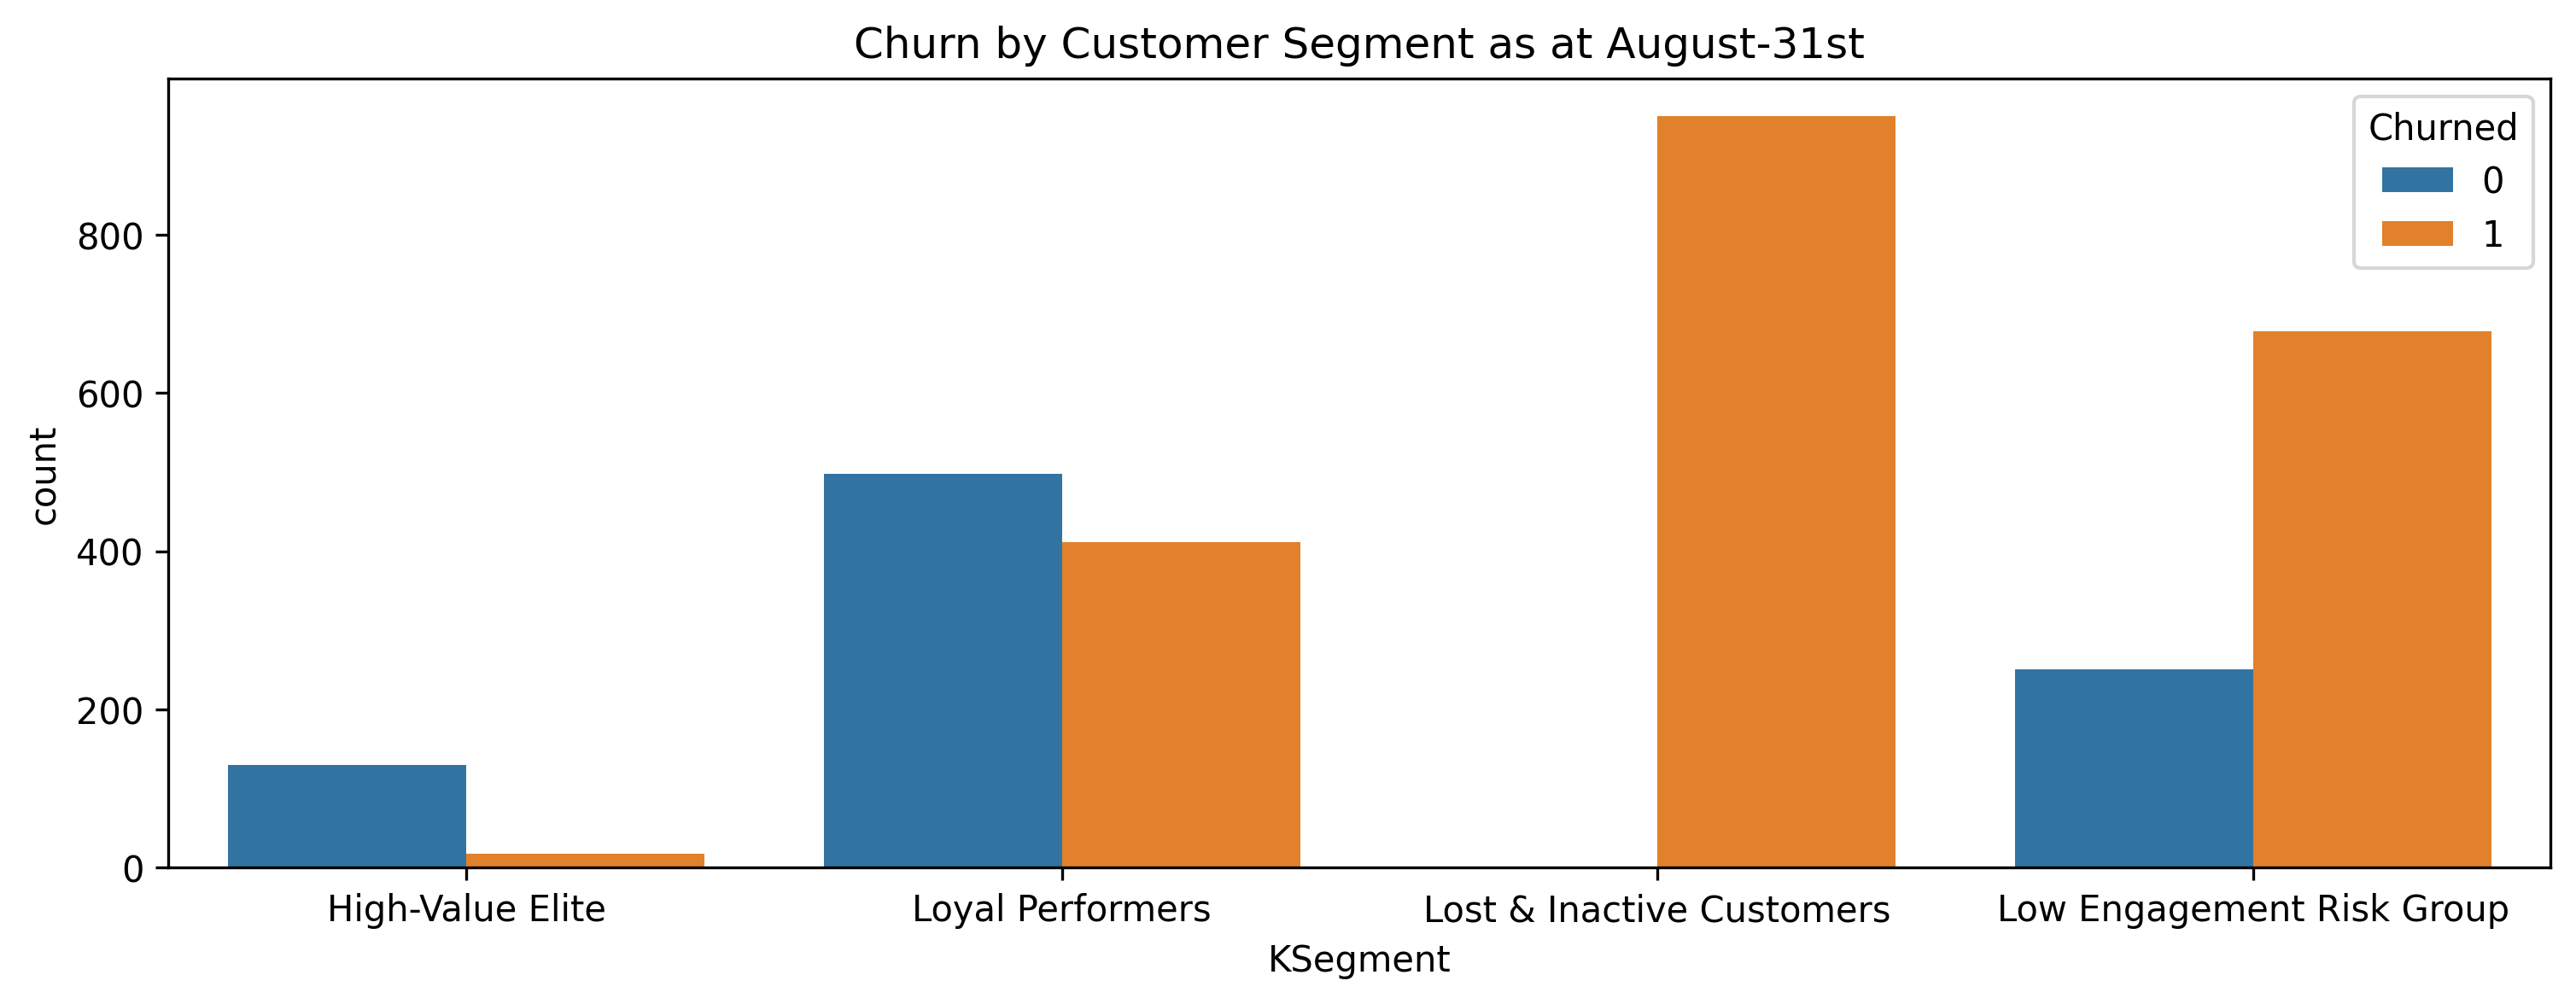

KSegment,High-Value Elite,Lost & Inactive Customers,Low Engagement Risk Group,Loyal Performers
Churned,,,,
0,130.000000,0.0,251.000000,498.000000
1,17.000000,950.0,678.000000,412.000000
ChurnRate,0.115646,1.0,0.729817,0.452747


In [ ]:
plt.figure(figsize = (12,4), dpi = 300)
sns.countplot(data = df, x = 'KSegment', hue = 'Churned')
plt.title("Churn by Customer Segment as at August-31st")
plt.show()

summary = df.groupby(['KSegment', 'Churned']).size().unstack().fillna(0)
summary["ChurnRate"] = (summary[1]/(summary[0] + summary[1]))

summary.stack().unstack(level =0)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = df.drop(['Churned', 'CustomerID'], axis = 1)
X = pd.get_dummies(X, drop_first = True)
features = X.columns
X = X.values

y = df['Churned'].values

customer_ids = df['CustomerID'].values

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(X, y, customer_ids, test_size=0.2, random_state = 42, stratify = y)

df_train, df_test = train_test_split(df['CustomerID'], test_size = 0.20, random_state = 42)

scaler = StandardScaler()

models = [("Logistic Regression", LogisticRegression(max_iter = 1000, class_weight = 'balanced')),
          ("Random Forest", RandomForestClassifier(random_state = 42, class_weight = 'balanced')),
          ("Decision Tree", DecisionTreeClassifier(random_state = 42, class_weight = 'balanced')),
          ("Xgboost", XGBClassifier(random_state = 42)),
          ("Lightgbm", LGBMClassifier(random_state = 42, class_weight = 'balanced', verbose = -1))]

model_name = []
accuracy_avg = []
precision_avg = []
recall_avg = []
for name, model in models:
  pipeline = make_pipeline(scaler, model)
  kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
  accuracy_scores = cross_val_score(pipeline, X_train, y_train, cv = kf, scoring = 'accuracy')
  precision_scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = 'precision')
  recall_scores = cross_val_score(model, X_train, y_train, cv = kf, scoring = 'recall')

  model_name.append(name)
  accuracy_avg.append(accuracy_scores)
  precision_avg.append(precision_scores)
  recall_avg.append(recall_scores)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

/tmp/ipykernel_2250/1547363700.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(accuracy_avg, labels = model_name)
/tmp/ipykernel_2250/1547363700.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(precision_avg, labels = model_name)
/tmp/ipykernel_2250/1547363700.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(recall_avg, labels = model_name)


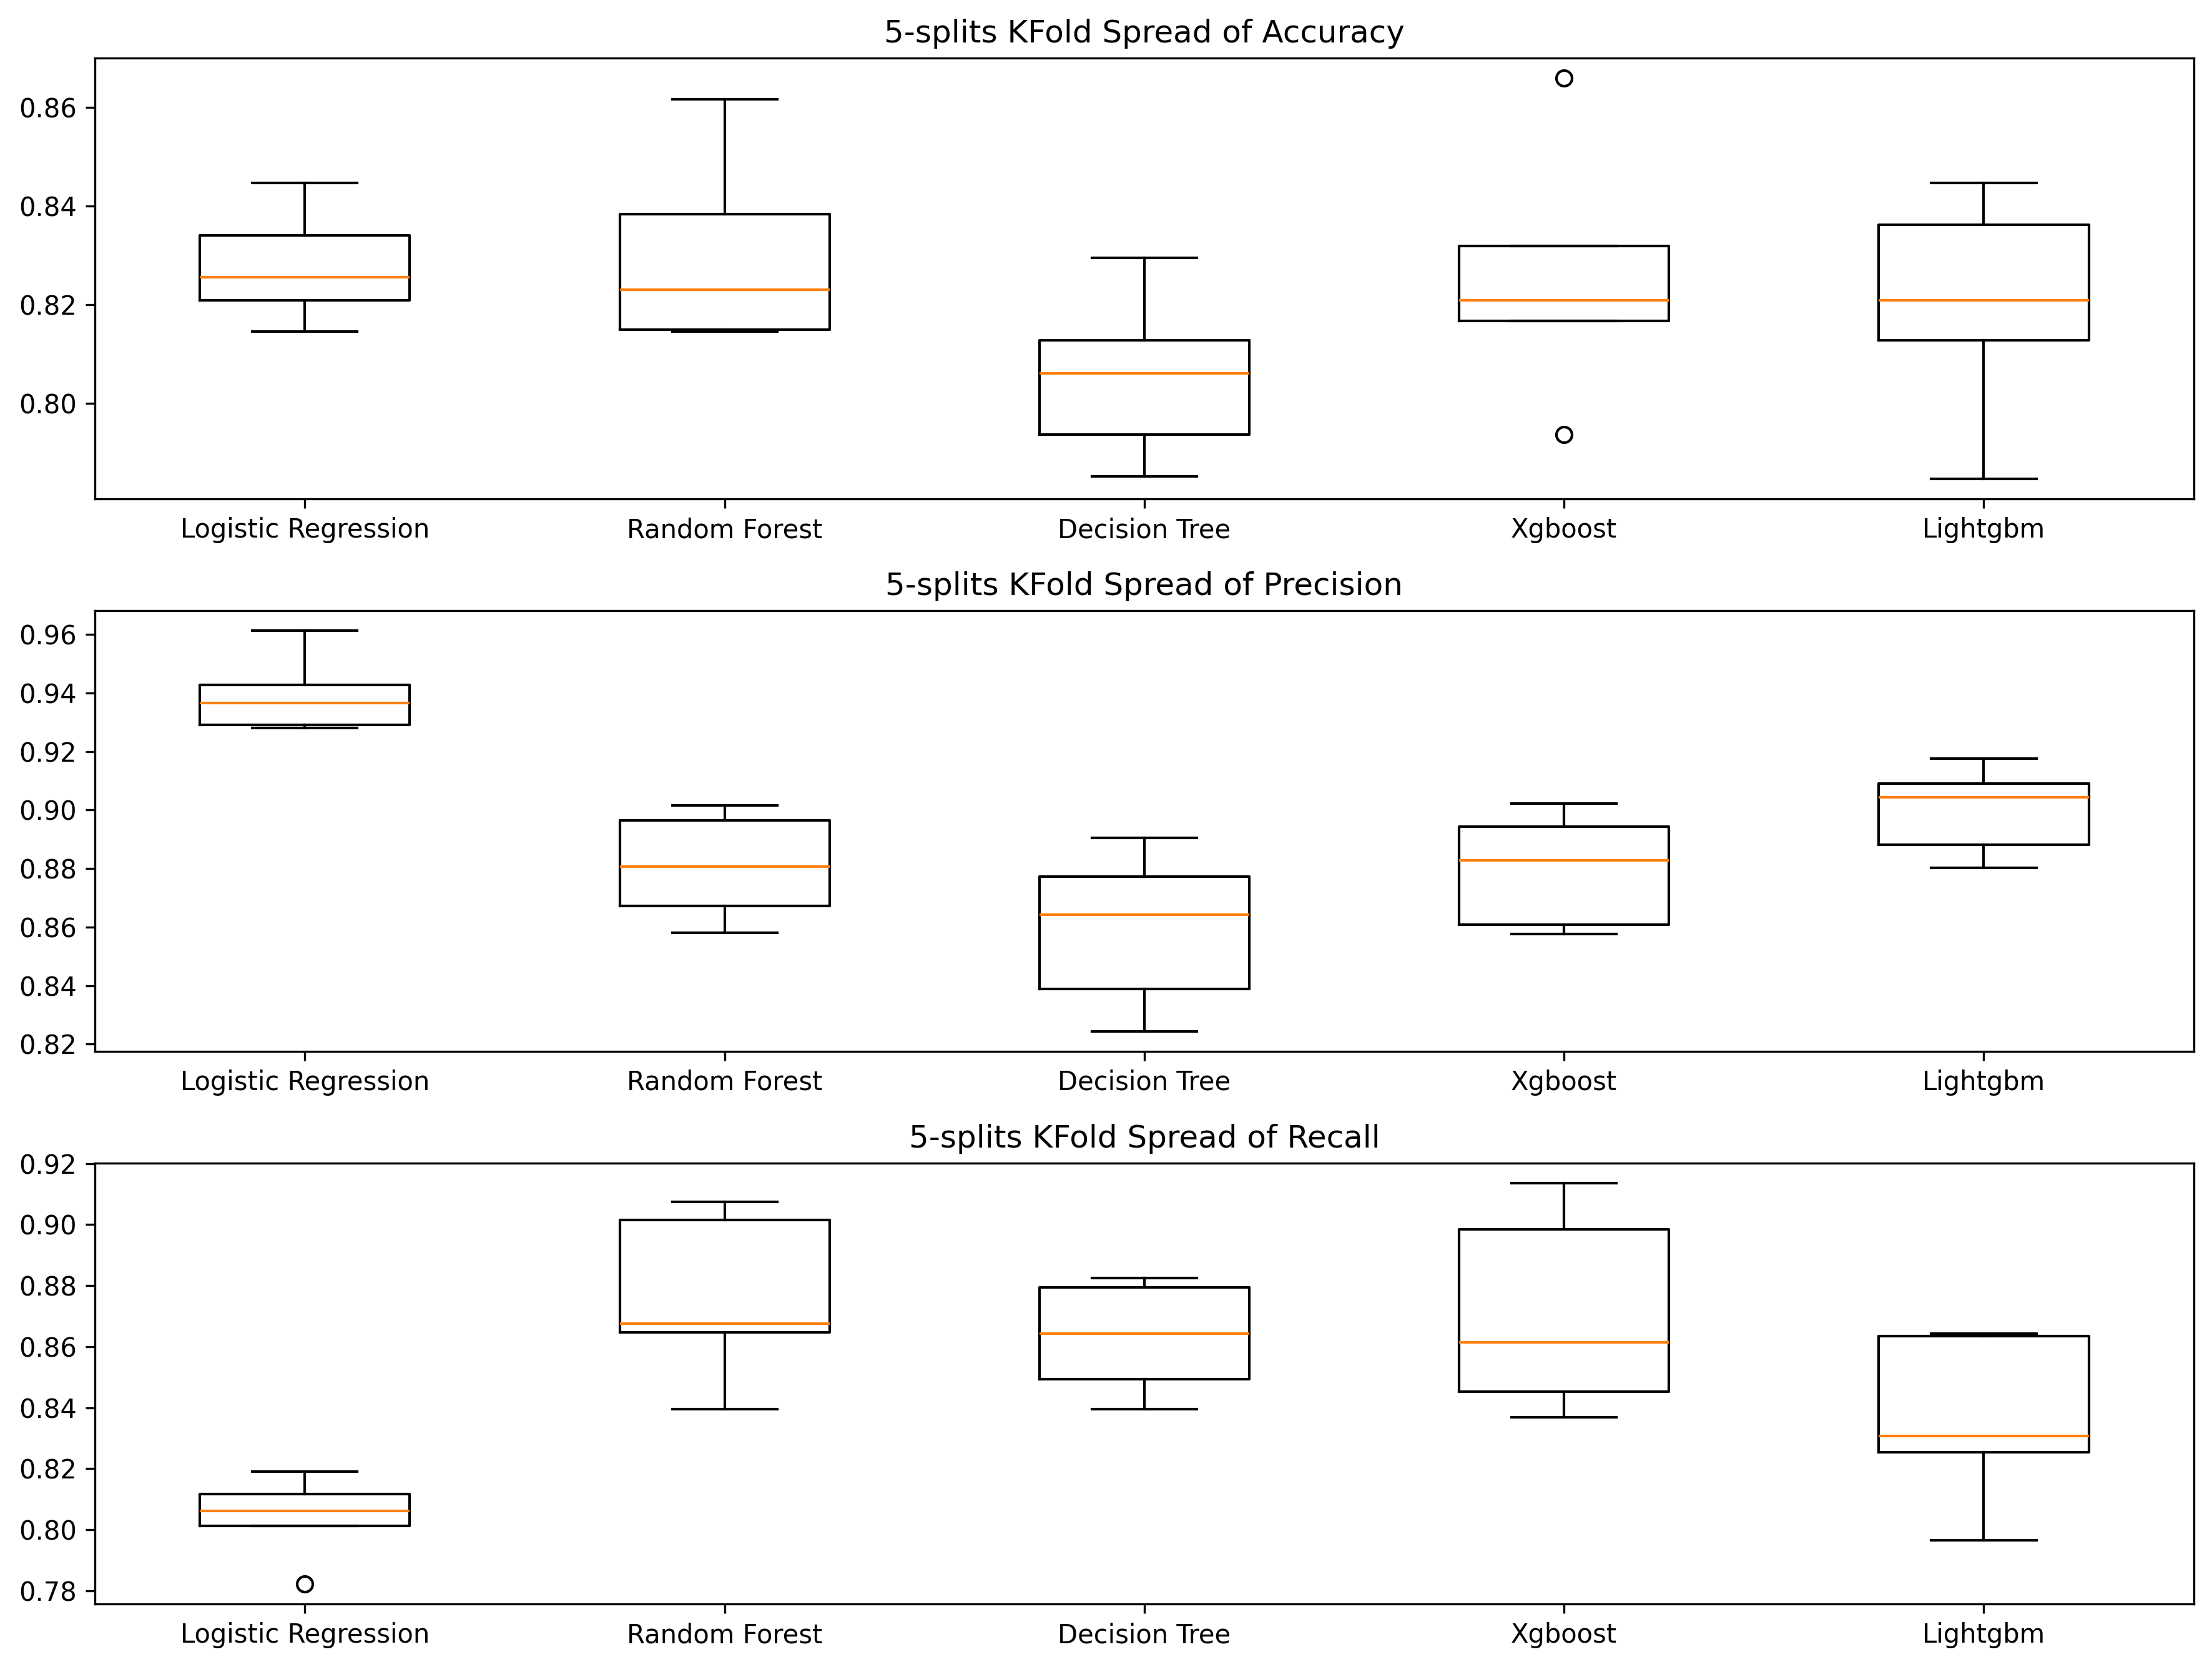

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize = (12,9), dpi = 300)
ax1.boxplot(accuracy_avg, labels = model_name)
ax1.set_title("5-splits KFold Spread of Accuracy")
ax2.boxplot(precision_avg, labels = model_name)
ax2.set_title("5-splits KFold Spread of Precision")
ax3.boxplot(recall_avg, labels = model_name)
ax3.set_title("5-splits KFold Spread of Recall")
plt.tight_layout()
plt.show()

Mounted at /content/drive
Successfully saved churn model to /content/drive/MyDrive/churn_model.joblib
Successfully loaded churn model from Google Drive


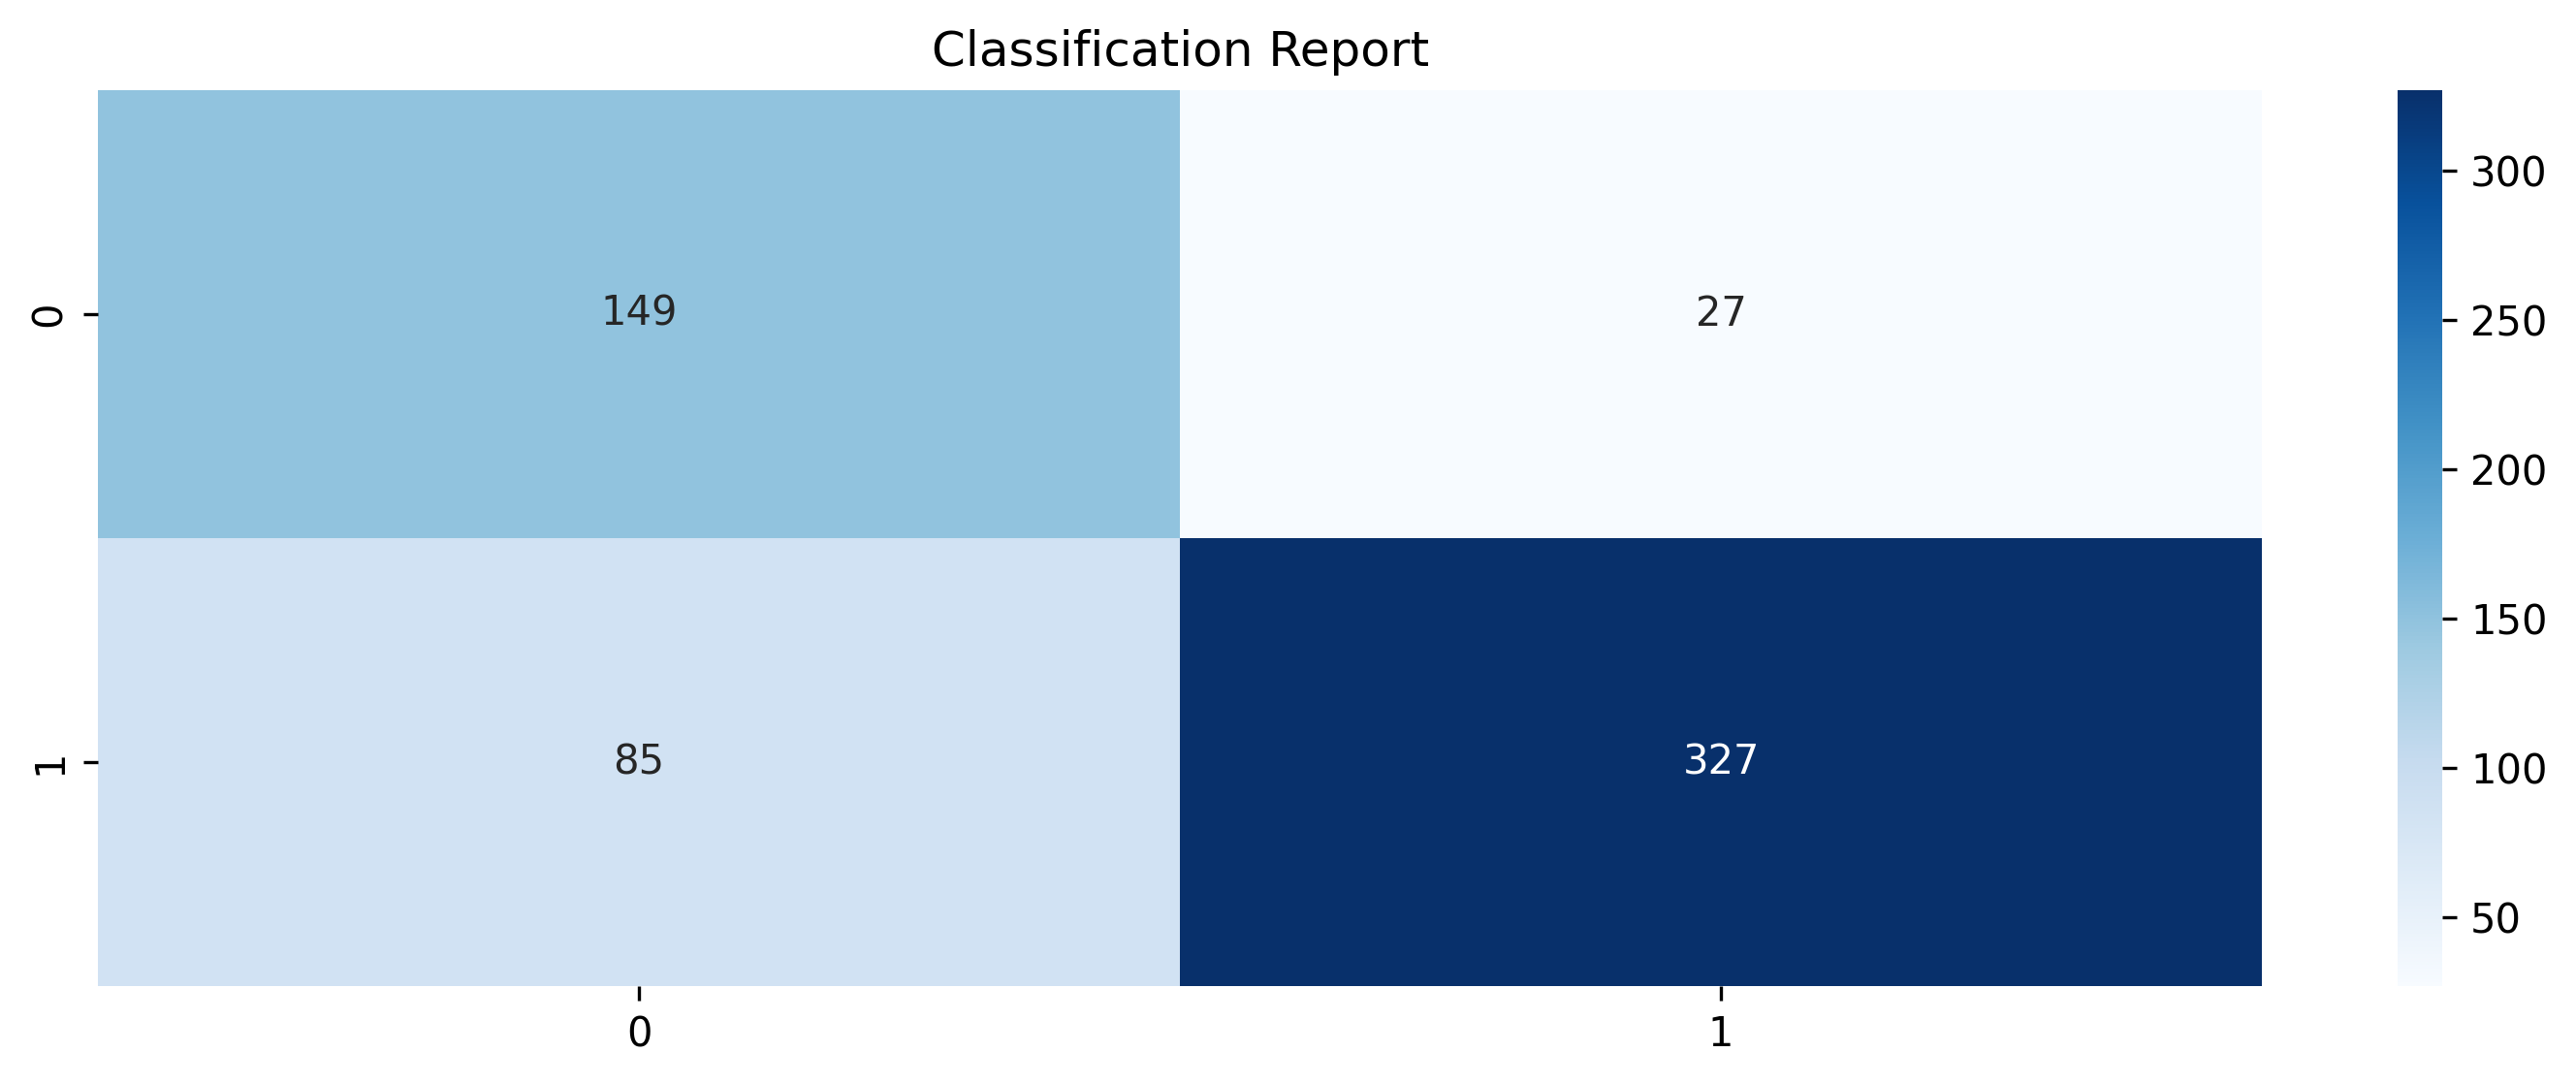

              precision    recall  f1-score   support

           0       0.64      0.85      0.73       176
           1       0.92      0.79      0.85       412

    accuracy                           0.81       588
   macro avg       0.78      0.82      0.79       588
weighted avg       0.84      0.81      0.82       588



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import joblib

churn_model_path = '/content/drive/MyDrive/churn_model.joblib'

model = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
pipeline = make_pipeline(scaler, model)
pipeline.fit(X_train, y_train)

joblib.dump(pipeline, churn_model_path)
print(f'Successfully saved churn model to {churn_model_path}')

loaded_model = joblib.load(churn_model_path)
print("Successfully loaded churn model from Google Drive")

y_pred = loaded_model.predict(X_test)
y_proba = loaded_model.predict_proba(X_test)[:,1]

c_matrix = confusion_matrix(y_test, y_pred)

# Creating predictions table in Database
pred_df = pd.DataFrame({
    "CustomerID" : ids_test,
    "ActualChurn": y_test,
    "PredictedProbability": y_proba,
    "PredictedLabel": y_pred
})

engine = create_engine(userdata.get('NEON_DATABASE_URL'))
#Creating Table of Predictions in Database
pred_df.to_sql(
    name = 'churn_test_predictions',
    con = engine,
    if_exists = 'replace',
    index = False
)

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(c_matrix, cmap='Blues', annot = True, fmt = 'g')
plt.title("Classification Report")
plt.show()

print(classification_report(y_test, y_pred))

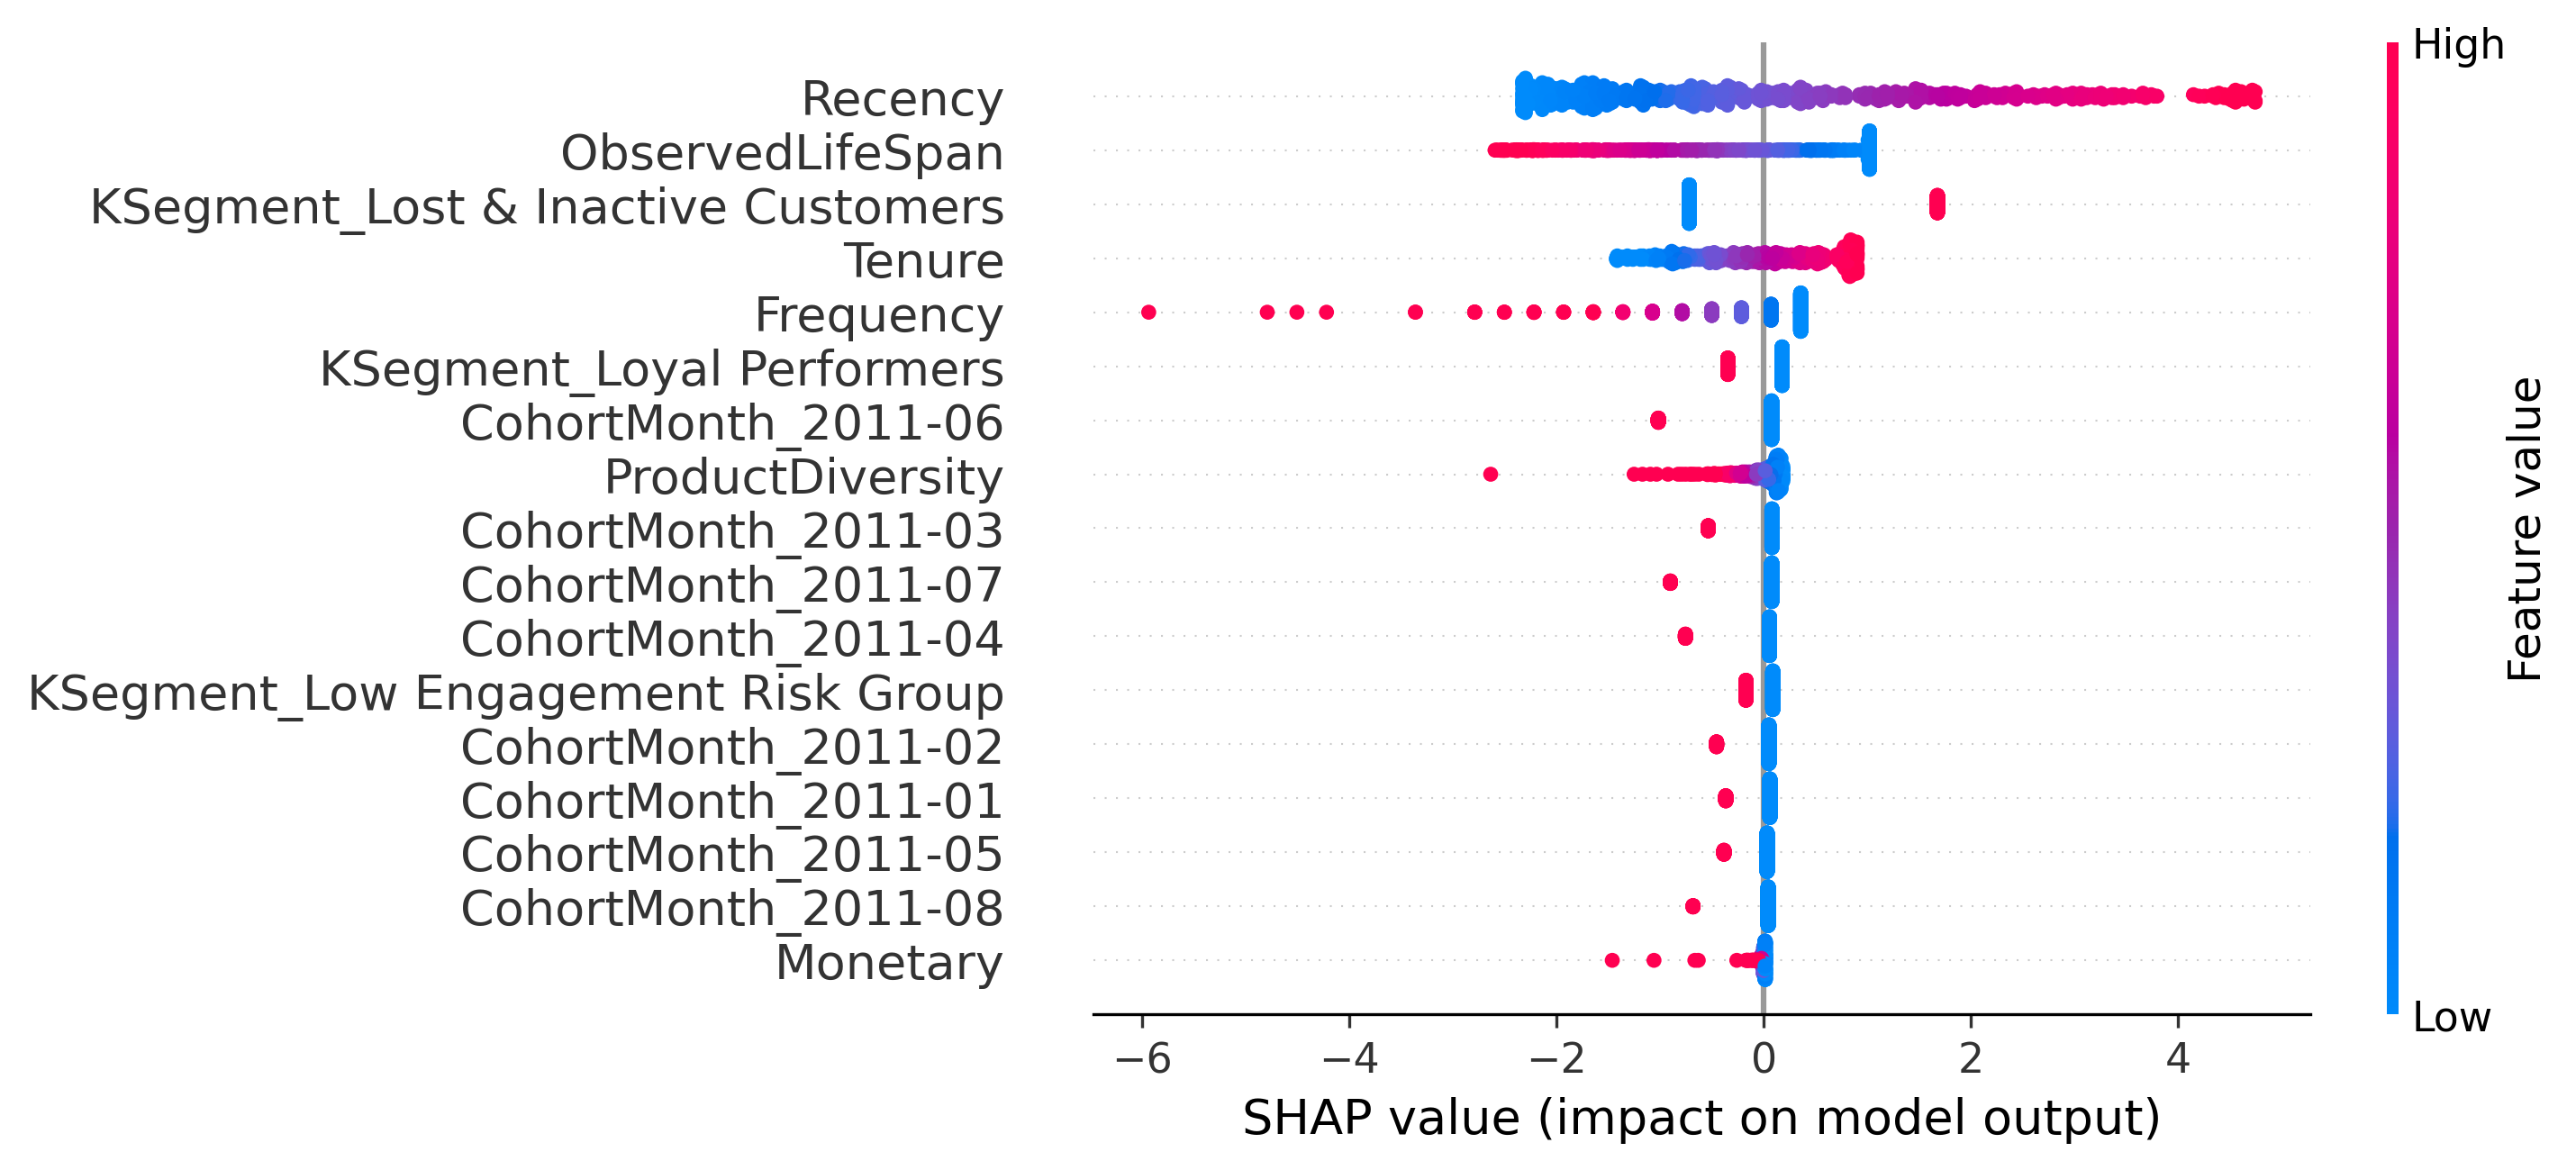

In [ ]:
import shap

X_train_scaled_df = pd.DataFrame(scaler.fit_transform(X_train), columns = features)
X_test_scaled_df = pd.DataFrame(scaler.transform(X_test), columns = features)

explainer = shap.LinearExplainer(model, X_train_scaled_df, max_samples = len(X_train_scaled_df))
shap_values = explainer(X_test_scaled_df)

plt.figure(dpi = 300)
shap.summary_plot(shap_values, X_test_scaled_df, show = False)
#plt.tight_layout()
plt.gcf().set_size_inches(12,4)
plt.show()

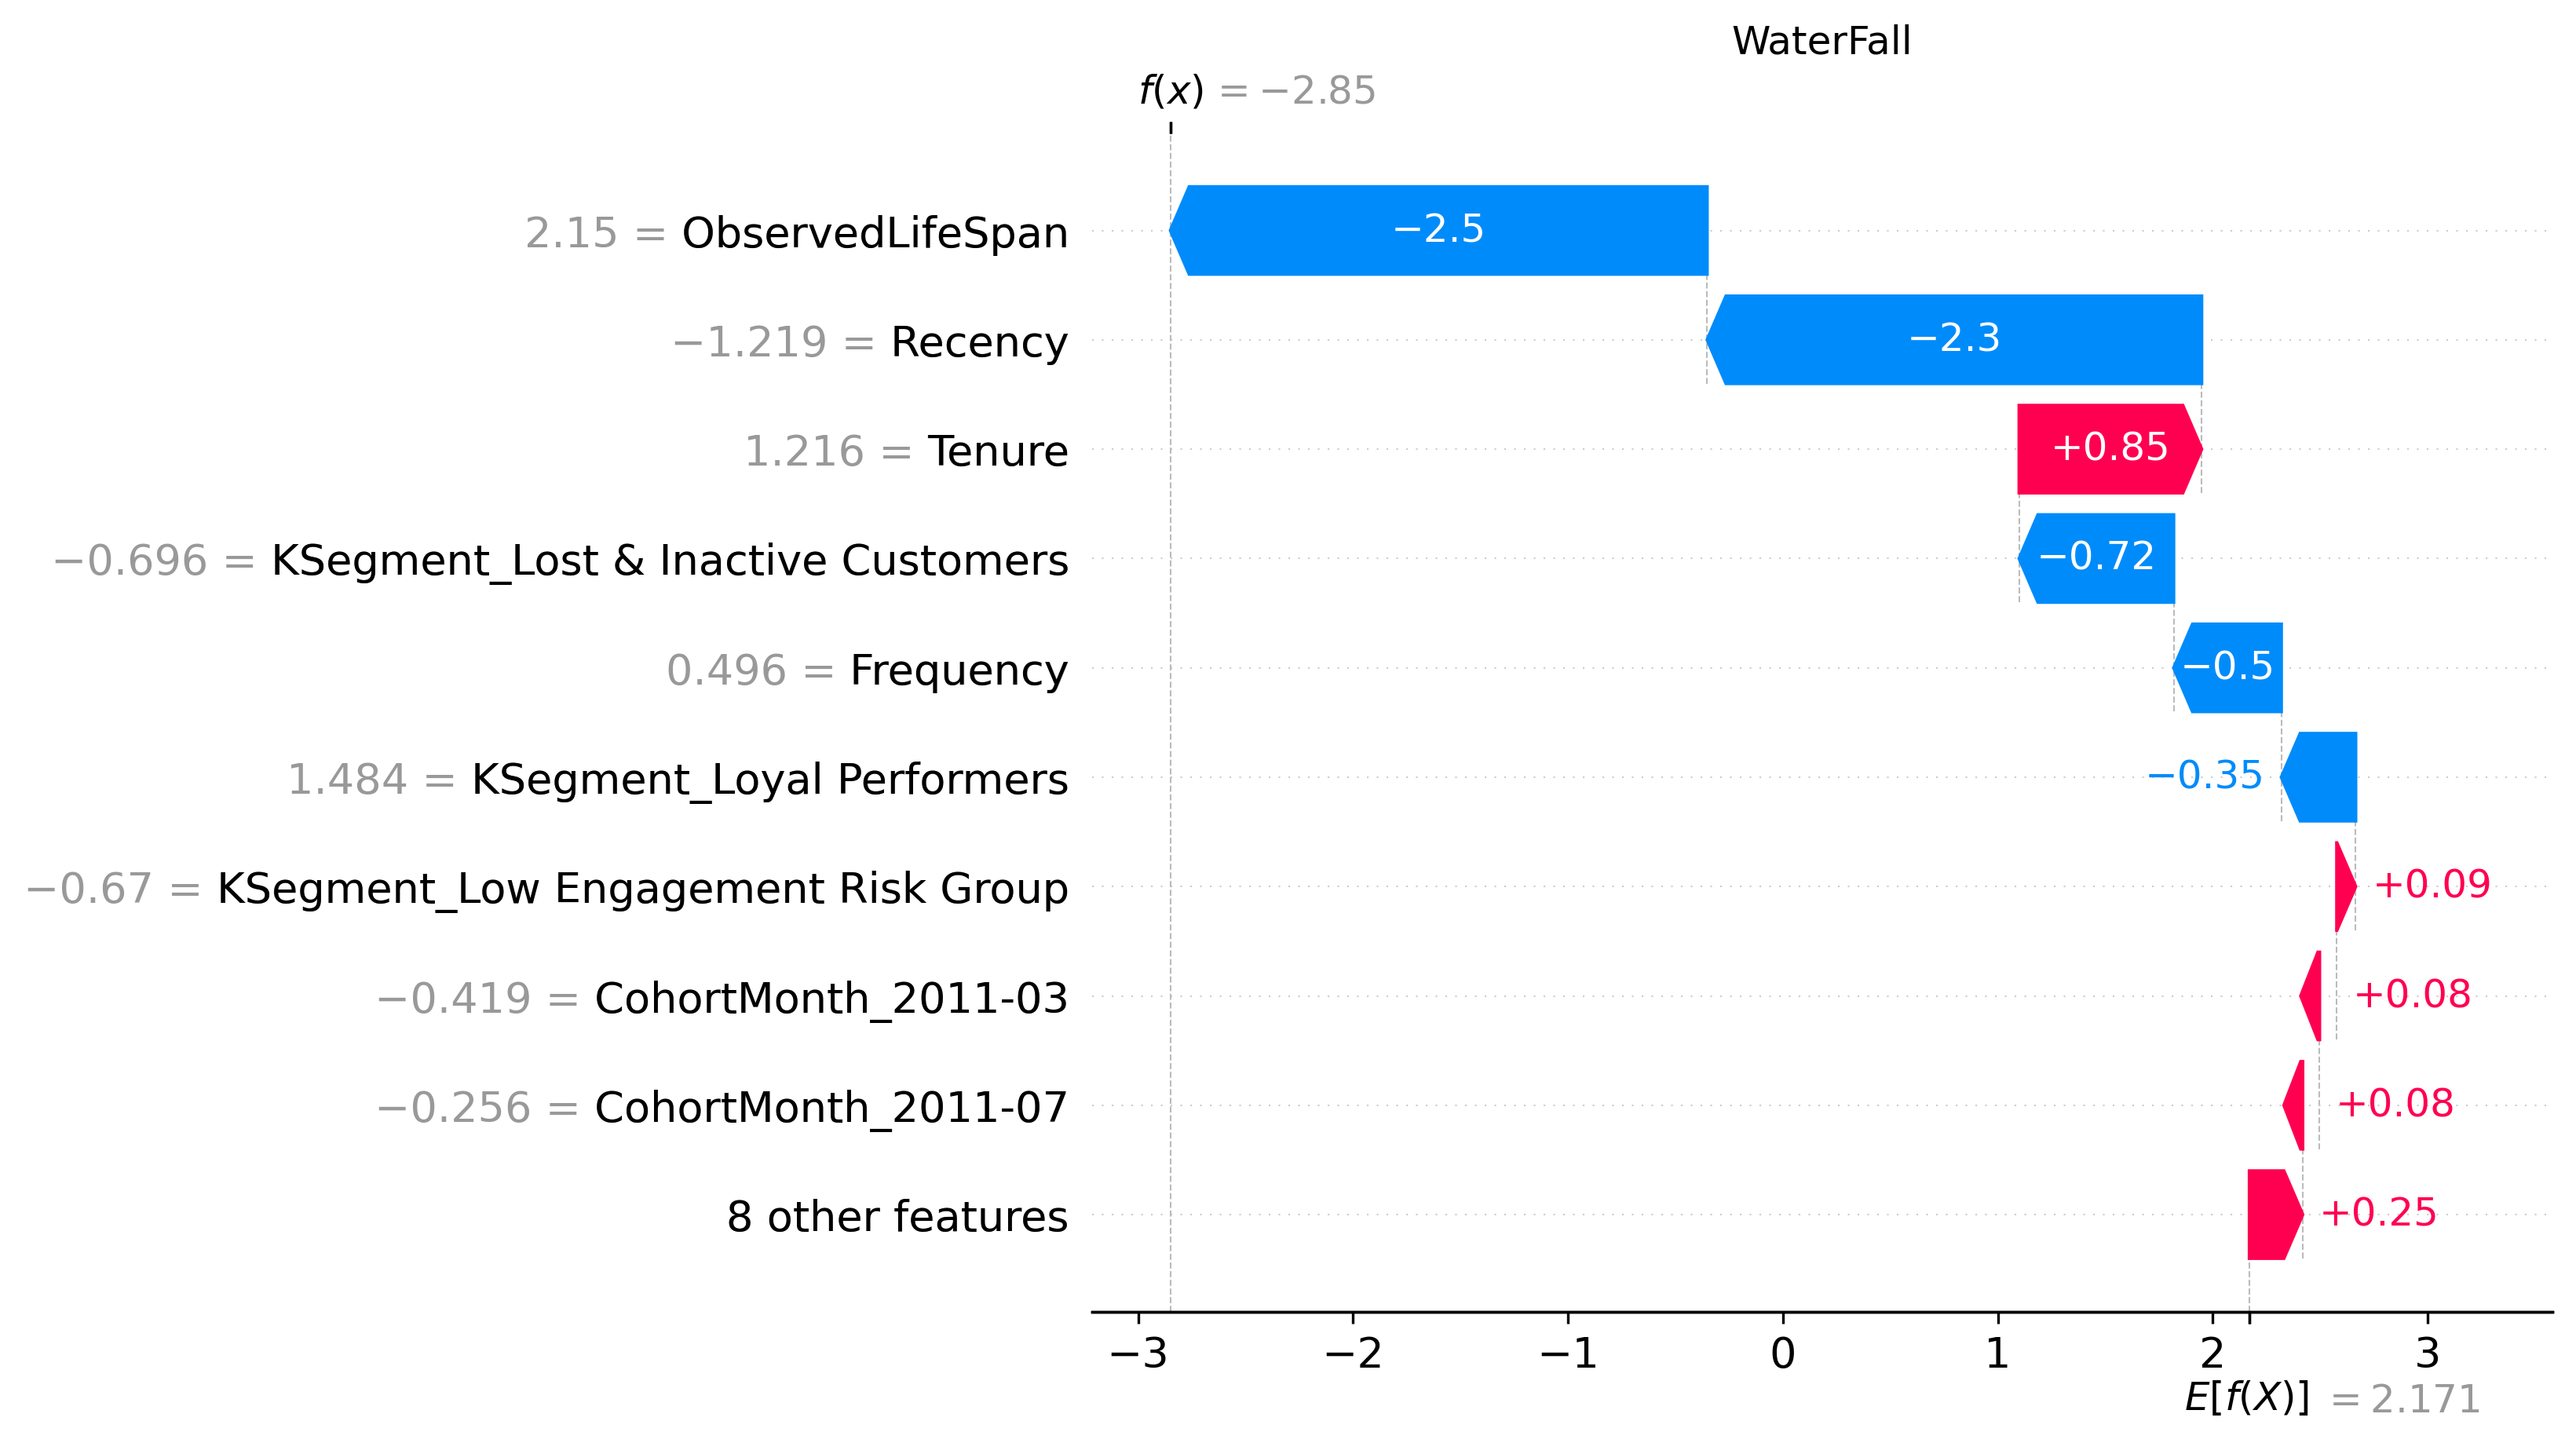

In [ ]:
plt.figure(dpi =300)
shap.plots.waterfall(shap_values[0], show = False)
#plt.gcf().set_size_inches(12,4)
plt.title("WaterFall")
plt.show()